In [59]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from utils.preprocess import train_test_split, add_indicators
from utils.ticker_data import windowed_dfs

In [60]:
df = pd.read_csv("data/daily/^GSPC.csv")
df['Date'] = pd.to_datetime(df.Date)
df = df.set_index('Date')

df.head()

,Open,High,Low,Close,Volume,logReturns
Date,,,,,,
2000-01-04,1455.219971,1455.219971,1397.430054,1399.420044,1009000000,-0.039099
2000-01-05,1399.420044,1413.270020,1377.680054,1402.109985,1085500000,0.001920
2000-01-06,1402.109985,1411.900024,1392.099976,1403.449951,1092300000,0.000955
2000-01-07,1403.449951,1441.469971,1400.729980,1441.469971,1225200000,0.026730
2000-01-10,1441.469971,1464.359985,1441.469971,1457.599976,1064800000,0.011128


In [61]:
df_indicators = add_indicators(df)
df_indicators.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'logReturns', 'RSI5', 'RSI10',
       'SMA_5', 'SMA_10', 'EMA_10', 'MACD', 'BB_upper', 'BB_middle',
       'BB_lower'],
      dtype='object')

In [62]:
x = df_indicators['Close']
print(x.iloc[:5])
scaler = StandardScaler()
x = scaler.fit_transform([x])
x.sum()

Date
2000-02-22    1352.170044
2000-02-23    1360.689941
2000-02-24    1353.430054
2000-02-25    1333.359985
2000-02-28    1348.050049
Name: Close, dtype: float64


np.float64(0.0)

In [63]:
columns = ['Close']
target = 'Close'
window_size = 30

scaler = StandardScaler()
for col in columns:
    df_indicators[col] = scaler.fit_transform(df_indicators[[col]])

X, y = windowed_dfs(df_indicators, columns=columns, target=target, train_window=window_size)

X.head()

,close-30,close-29,close-28,close-27,close-26,close-25,close-24,close-23,close-22,close-21,...,close-10,close-9,close-8,close-7,close-6,close-5,close-4,close-3,close-2,close-1
0,-0.626057,-0.619703,-0.625117,-0.640086,-0.629130,-0.615429,-0.605905,-0.603988,-0.583546,-0.596888,...,-0.520375,-0.515326,-0.495405,-0.495323,-0.498008,-0.510038,-0.509449,-0.524812,-0.516862,-0.511350
1,-0.619703,-0.625117,-0.640086,-0.629130,-0.615429,-0.605905,-0.603988,-0.583546,-0.596888,-0.623484,...,-0.515326,-0.495405,-0.495323,-0.498008,-0.510038,-0.509449,-0.524812,-0.516862,-0.511350,-0.519733
2,-0.625117,-0.640086,-0.629130,-0.615429,-0.605905,-0.603988,-0.583546,-0.596888,-0.623484,-0.615221,...,-0.495405,-0.495323,-0.498008,-0.510038,-0.509449,-0.524812,-0.516862,-0.511350,-0.519733,-0.525223
3,-0.640086,-0.629130,-0.615429,-0.605905,-0.603988,-0.583546,-0.596888,-0.623484,-0.615221,-0.589124,...,-0.495323,-0.498008,-0.510038,-0.509449,-0.524812,-0.516862,-0.511350,-0.519733,-0.525223,-0.514804
4,-0.629130,-0.615429,-0.605905,-0.603988,-0.583546,-0.596888,-0.623484,-0.615221,-0.589124,-0.594062,...,-0.498008,-0.510038,-0.509449,-0.524812,-0.516862,-0.511350,-0.519733,-0.525223,-0.514804,-0.503609


In [64]:
X_train, y_train, X_test, y_test, test_dates = train_test_split(X, y, df.index, window_size=window_size)
(X_train.shape, y_train.shape, X_test.shape, y_test.shape, test_dates.shape)

((6258, 30), (6258,), (67, 30), (67,), (130,))

In [65]:
from sklearn.svm import SVR
model = SVR(kernel='rbf', C=1.0, epsilon=0.01)
model.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.01
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [66]:
y_pred = model.predict(X_test)

In [67]:
y_test = scaler.inverse_transform(y_test.reshape(-1,1))
y_pred = scaler.inverse_transform(y_pred.reshape(-1,1))

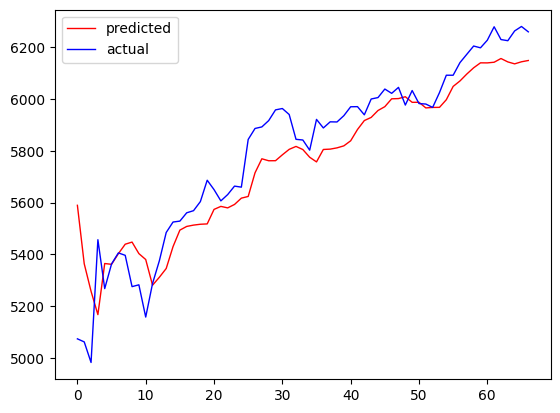

In [68]:
plt.plot(y_pred, c = 'r', lw = 1, label = 'predicted')
plt.plot(y_test, c='b', lw = 1, label = 'actual')

plt.legend()
plt.show()

In [69]:
from sklearn.metrics import mean_absolute_percentage_error
print(mean_absolute_percentage_error(y_test, y_pred))

0.017581677900291352
